In [23]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import pfhedge
import pysiglib.torch_api as siglib
from pfhedge.instruments import BrownianStock
from pfhedge.instruments import EuropeanOption

from pfhedge.nn import Hedger
from pfhedge.nn import MultiLayerPerceptron
from pfhedge.nn.functional import entropic_risk_measure
from pfhedge.nn import BlackScholes
from pfhedge.features._base import StateIndependentFeature




In [24]:
torch.manual_seed(6)
N_PATHS = 50000
N_EPOCHS = 100

In [25]:
data = pd.read_csv("IBM.csv")
data["Date"] = pd.to_datetime(data["Date"])

In [26]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13642 entries, 0 to 13641
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Unnamed: 0  13642 non-null  int64         
 1   Date        13642 non-null  datetime64[us]
 2   Open_IBM    13642 non-null  float64       
 3   High_IBM    13642 non-null  float64       
 4   Low_IBM     13642 non-null  float64       
 5   Close_IBM   13642 non-null  float64       
 6   Volume_IBM  13642 non-null  int64         
dtypes: datetime64[us](1), float64(4), int64(2)
memory usage: 746.2 KB


In [27]:
T_start = len(data)-100

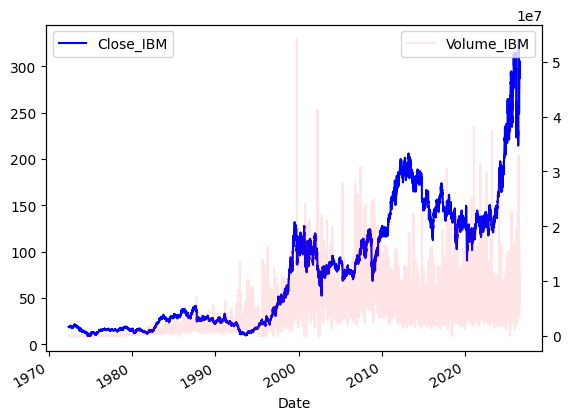

In [28]:
ax1 = data.plot(x="Date", y="Close_IBM", color="blue")
ax2 = ax1.twinx()
data.plot(x="Date", y="Volume_IBM", ax=ax2, color="red",alpha=0.1)
plt.show()

In [29]:
historical_prices = data["Close_IBM"].iloc[T_start:].copy()

s0 = float(historical_prices.iloc[0])
historical_prices_normalized = historical_prices / s0

x1 = np.log(historical_prices_normalized).diff().dropna()


In [30]:
daily_mean = x1.mean()
daily_vol = x1.std(ddof=1)

sigma = daily_vol * np.sqrt(250)
mu = daily_mean * 250 + 0.5 * sigma**2

stock_GBM = BrownianStock(
    mu=0,
    sigma=sigma,
    dt=1 / 250,
)


In [31]:
K = 1
print(K)

1


torch.Size([50000, 100])

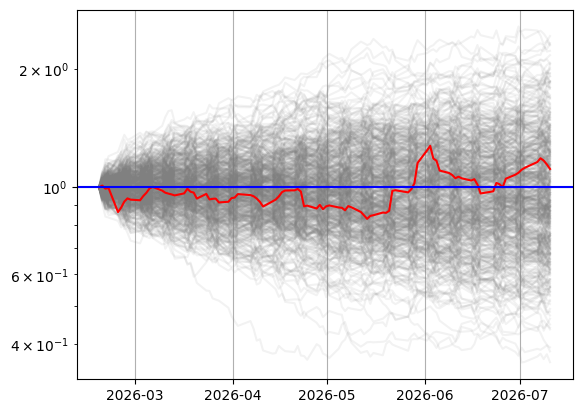

In [32]:
stock_GBM.simulate(n_paths=N_PATHS, time_horizon = len(x1) / 250) 
paths_GBM = stock_GBM.spot

plt.plot(data["Date"][T_start:],paths_GBM[0:500].T,alpha=0.1,color="grey")
plt.plot(data["Date"][T_start:],historical_prices_normalized,color="red")
plt.axhline(K,color="blue")
plt.yscale("log")
plt.grid()
paths_GBM.shape

{'pricer': None, 'cost': 0.0, '_clauses': OrderedDict(), '_underliers': OrderedDict([('underlier', BrownianStock(sigma=0.5201, dt=0.0040))]), 'call': True, 'strike': 1, 'maturity': 0.08}


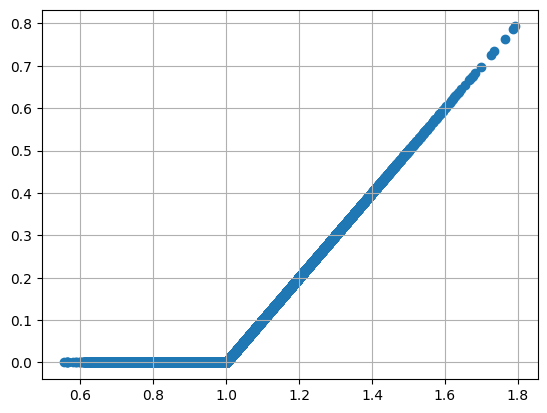

In [33]:
EuropeanCallOption = EuropeanOption(stock_GBM,strike=K,maturity=20/250)
derivative = EuropeanCallOption

print(EuropeanCallOption.__dict__)
EuropeanCallOption.simulate(N_PATHS) # Runs MonteCarlo simulation for the option
payoff = EuropeanCallOption.payoff_fn()
underlying = EuropeanCallOption.ul() # ul() returns the underlying asset
terminal_prices = underlying.spot[:, -1]  # Simulated prices at expiration
plt.scatter(terminal_prices, payoff)
plt.grid()

In [34]:
def fourier_features(log_path, K=3):
    # Compute only the requested coefficients, avoiding a full FFT.
    window = log_path.shape[-1]
    sample = torch.arange(window, device=log_path.device, dtype=log_path.dtype)
    frequency = torch.arange(K + 1, device=log_path.device, dtype=log_path.dtype)
    angle = 2 * torch.pi * frequency[:, None] * sample[None, :] / window
    scale = window ** -0.5

    real = scale * torch.einsum("...w,kw->...k", log_path, torch.cos(angle))
    imag = -scale * torch.einsum("...w,kw->...k", log_path, torch.sin(angle))

    return torch.cat([real[..., :1], real[..., 1:], imag[..., 1:]], dim=-1)


class RollingFourierFeature(StateIndependentFeature):
    def __init__(self, history_prices, K=3):
        super().__init__()

        history = torch.as_tensor(
            np.asarray(history_prices),
            dtype=torch.get_default_dtype(),
        )

        if history.ndim != 1:
            raise ValueError("history_prices must be one-dimensional")

        if history.numel() != 100:
            raise ValueError(
                f"Expected 100 historical prices, received {history.numel()}"
            )

        if torch.any(history <= 0):
            raise ValueError("history_prices must be positive")

        self.history_log_relative = torch.log(history / history[-1])
        self.window = history.numel()
        self.K = K

        if K >= self.window // 2 + 1:
            raise ValueError("K is too large for the history window")

    def __str__(self):
        return f"rolling_fourier_{self.K}"

    def get(self, time_step=None):
        spot = self.derivative.ul().spot
        log_spot = torch.log(spot)

        history = self.history_log_relative.to(spot)
        log_strike = spot.new_tensor(self.derivative.strike).log()

        # Align historical data so its final value equals simulated S_0
        historical_log_moneyness = (
            history[:-1].unsqueeze(0)
            + log_spot[:, :1]
            - log_strike
        )

        simulated_log_moneyness = log_spot - log_strike

        complete_path = torch.cat(
            [
                historical_log_moneyness.expand(spot.shape[0], -1),
                simulated_log_moneyness,
            ],
            dim=1,
        )

        # Shape: (n_paths, n_times, history_window)
        rolling_windows = complete_path.unfold(
            dimension=1,
            size=self.window,
            step=1,
        )

        features = fourier_features(
            rolling_windows,
            K=self.K,
        )

        if time_step is not None:
            features = features[:, time_step:time_step + 1, :]

        return features

In [35]:
K = 3
fourier_feature = RollingFourierFeature(
    history_prices=historical_prices.to_numpy(copy=True),
    K=K,
)

model1f = MultiLayerPerceptron(
    in_features=1 + 2 * K,
    n_units=16,
    n_layers=3,
)

hedger1f = Hedger(
    model1f,
    inputs=[fourier_feature],
)

print(hedger1f)
print(hedger1f.model)

Hedger(
  inputs=['rolling_fourier_3']
  (model): MultiLayerPerceptron(
    (0): Linear(in_features=7, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Identity()
  )
  (criterion): EntropicRiskMeasure()
)
MultiLayerPerceptron(
  (0): Linear(in_features=7, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=16, bias=True)
  (5): ReLU()
  (6): Linear(in_features=16, out_features=1, bias=True)
  (7): Identity()
)


### Depth-3 path-signature representation

For each hedge time, the feature uses the most recent 100 observations of the two-dimensional path $(t, \log(S_t/K))$. A fixed origin is prepended so that the signature retains the absolute time and moneyness levels. With two channels and depth three, the scalar level is omitted and the network receives $2 + 2^2 + 2^3 = 14$ coefficients.


In [36]:
class RollingSignatureFeature(StateIndependentFeature):
    """Rolling signature of a basepointed (time, log-moneyness) path."""

    def __init__(self, history_prices, depth=3):
        super().__init__()

        history = torch.as_tensor(
            np.asarray(history_prices),
            dtype=torch.get_default_dtype(),
        )

        if history.ndim != 1:
            raise ValueError("history_prices must be one-dimensional")

        if history.numel() != 100:
            raise ValueError(
                f"Expected 100 historical prices, received {history.numel()}"
            )

        if torch.any(history <= 0):
            raise ValueError("history_prices must be positive")

        if depth < 1:
            raise ValueError("depth must be positive")

        self.history_log_relative = torch.log(history / history[-1])
        self.window = history.numel()
        self.depth = depth
        self.n_channels = 2
        self.n_features = sum(
            self.n_channels ** level
            for level in range(1, depth + 1)
        )

    def __str__(self):
        return f"rolling_signature_{self.depth}"

    def get(self, time_step=None):
        spot = self.derivative.ul().spot
        n_paths, n_times = spot.shape

        with torch.no_grad():
            log_spot = torch.log(spot)
            log_strike = spot.new_tensor(self.derivative.strike).log()
            history = self.history_log_relative.to(spot)

            # Align the historical path so that its final value equals S_0.
            historical_log_moneyness = (
                history[:-1].unsqueeze(0)
                + log_spot[:, :1]
                - log_strike
            )
            simulated_log_moneyness = log_spot - log_strike

            complete_log_moneyness = torch.cat(
                [
                    historical_log_moneyness.expand(n_paths, -1),
                    simulated_log_moneyness,
                ],
                dim=1,
            )

            # Absolute increasing time, scaled by the 100-point window.
            # Together with the fixed origin, this retains the hedge time.
            complete_time = torch.arange(
                1,
                complete_log_moneyness.shape[1] + 1,
                device=spot.device,
                dtype=spot.dtype,
            ) / self.window

            if time_step is None:
                indices = range(n_times)
            else:
                time_step = int(time_step)
                if not 0 <= time_step < n_times:
                    raise IndexError("time_step is outside the simulated path")
                indices = (time_step,)

            features = []

            # Process one hedge time at a time. This avoids materialising
            # (n_paths, n_times, window, channels) in memory.
            for index in indices:
                path = spot.new_zeros(
                    (n_paths, self.window + 1, self.n_channels)
                )
                path[:, 1:, 0] = complete_time[
                    index:index + self.window
                ]
                path[:, 1:, 1] = complete_log_moneyness[
                    :, index:index + self.window
                ]

                signature = siglib.sig(
                    path.contiguous(),
                    degree=self.depth,
                    scalar_term=False,
                )

                if signature.shape[-1] != self.n_features:
                    raise RuntimeError(
                        "Unexpected number of signature coefficients"
                    )

                features.append(signature)

        return torch.stack(features, dim=1)


In [37]:
SIGNATURE_DEPTH = 2

signature_feature = RollingSignatureFeature(
    history_prices=historical_prices.to_numpy(copy=True),
    depth=SIGNATURE_DEPTH,
)

model1s = MultiLayerPerceptron(
    in_features=signature_feature.n_features,
    n_units=16,
    n_layers=3,
)

hedger1s = Hedger(
    model1s,
    inputs=[signature_feature],
)

print(f"Signature depth: {SIGNATURE_DEPTH}")
print(f"Signature features: {signature_feature.n_features}")
print(hedger1s)
print(hedger1s.model)


Signature depth: 2
Signature features: 6
Hedger(
  inputs=['rolling_signature_2']
  (model): MultiLayerPerceptron(
    (0): Linear(in_features=6, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Identity()
  )
  (criterion): EntropicRiskMeasure()
)
MultiLayerPerceptron(
  (0): Linear(in_features=6, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=16, bias=True)
  (5): ReLU()
  (6): Linear(in_features=16, out_features=1, bias=True)
  (7): Identity()
)


In [38]:
model1 = MultiLayerPerceptron(
    in_features=3,
    n_units=16,
    n_layers=3,
)




hedger1 = Hedger(model1, inputs=["log_moneyness", "expiry_time", "volatility"])

print(hedger1)
print(hedger1.model)

Hedger(
  inputs=['log_moneyness', 'expiry_time', 'volatility']
  (model): MultiLayerPerceptron(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Identity()
  )
  (criterion): EntropicRiskMeasure()
)
MultiLayerPerceptron(
  (0): Linear(in_features=3, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=16, bias=True)
  (5): ReLU()
  (6): Linear(in_features=16, out_features=1, bias=True)
  (7): Identity()
)


In [39]:
class IndependentNets(nn.Module):
    def __init__(self, N):
        super().__init__()
        self.nets = nn.ModuleList([
            MultiLayerPerceptron(
                in_features=3,
                n_units=16,
                n_layers=3,
            )
            for _ in range(N)
        ])

    def forward(self, x):
        # x has shape (n_paths, N + 1, 3)
        outputs = [
            net(x[..., i:i + 1, :])
            for i, net in enumerate(self.nets)
        ]

        # PFHedge expects an output at maturity too
        return torch.cat(outputs + [outputs[-1]], dim=-2)


N = derivative.ul().spot.shape[-1] - 1

modelN = IndependentNets(N)

hedgerN = Hedger(
    modelN,
    inputs=["log_moneyness", "expiry_time", "volatility"],
)

print(hedgerN)
print(hedgerN.model)

Hedger(
  inputs=['log_moneyness', 'expiry_time', 'volatility']
  (model): IndependentNets(
    (nets): ModuleList(
      (0-19): 20 x MultiLayerPerceptron(
        (0): Linear(in_features=3, out_features=16, bias=True)
        (1): ReLU()
        (2): Linear(in_features=16, out_features=16, bias=True)
        (3): ReLU()
        (4): Linear(in_features=16, out_features=16, bias=True)
        (5): ReLU()
        (6): Linear(in_features=16, out_features=1, bias=True)
        (7): Identity()
      )
    )
  )
  (criterion): EntropicRiskMeasure()
)
IndependentNets(
  (nets): ModuleList(
    (0-19): 20 x MultiLayerPerceptron(
      (0): Linear(in_features=3, out_features=16, bias=True)
      (1): ReLU()
      (2): Linear(in_features=16, out_features=16, bias=True)
      (3): ReLU()
      (4): Linear(in_features=16, out_features=16, bias=True)
      (5): ReLU()
      (6): Linear(in_features=16, out_features=1, bias=True)
      (7): Identity()
    )
  )
)


In [40]:
history1 = hedger1.fit(derivative, n_epochs=N_EPOCHS, n_paths=N_PATHS,n_times=5)

Loss=0.0595: 100%|██████████| 100/100 [00:35<00:00,  2.81it/s]


In [41]:
historyN = hedgerN.fit(derivative, n_epochs=N_EPOCHS, n_paths=N_PATHS,n_times=5)

Loss=0.0596: 100%|██████████| 100/100 [00:44<00:00,  2.25it/s]


In [42]:
historyf = hedger1f.fit(derivative, n_epochs=N_EPOCHS, n_paths=N_PATHS,n_times=5)

Loss=0.0596: 100%|██████████| 100/100 [01:14<00:00,  1.34it/s]


In [43]:
historys = hedger1s.fit(
    derivative,
    n_epochs=N_EPOCHS,
    n_paths=N_PATHS,
    n_times=5,
)


Loss=0.0596: 100%|██████████| 100/100 [20:13<00:00, 12.14s/it]


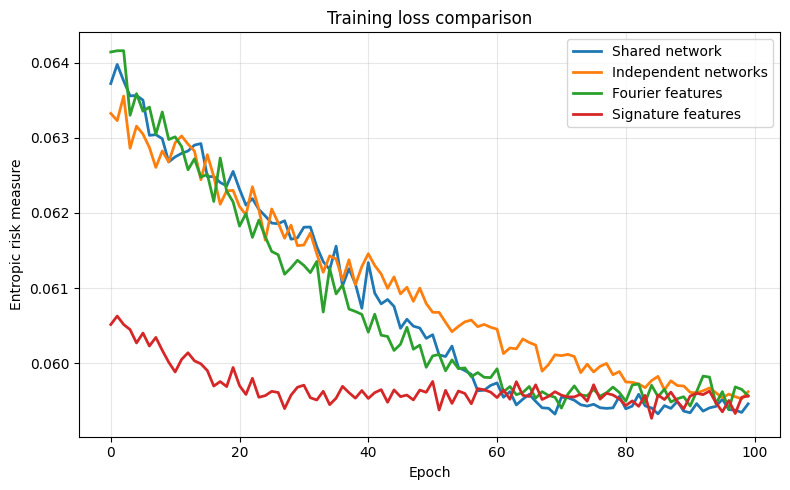

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(history1, label="Shared network", linewidth=2)
plt.plot(historyN, label="Independent networks", linewidth=2)
plt.plot(historyf, label="Fourier features", linewidth=2)
plt.plot(historys, label="Signature features", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Entropic risk measure")
plt.title("Training loss comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [45]:
def to_numpy(tensor: torch.Tensor) -> np.array:
    return tensor.detach().numpy()

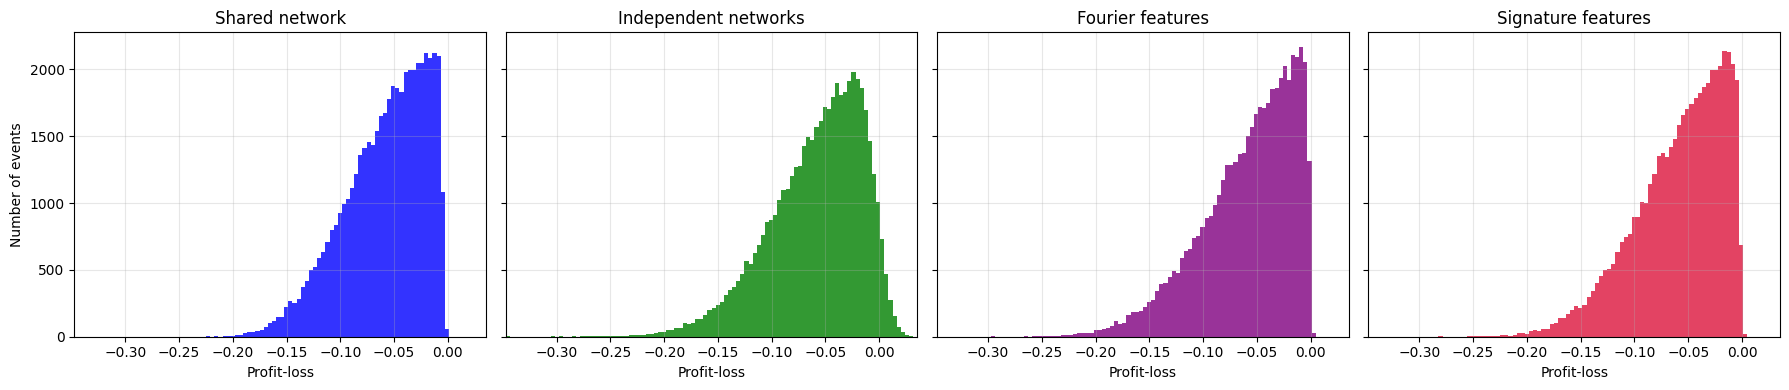

In [46]:
with torch.no_grad():
    pnl1 = hedger1.compute_pl(derivative).cpu()
    pnlN = hedgerN.compute_pl(derivative).cpu()
    pnlf = hedger1f.compute_pl(derivative).cpu()
    pnls = hedger1s.compute_pl(derivative).cpu()

all_pnl = torch.cat([pnl1, pnlN, pnlf, pnls])
xmin = all_pnl.min().item()
xmax = all_pnl.max().item()
bins = np.linspace(xmin, xmax, 101)

plots = [
    (pnl1, "Shared network", "blue"),
    (pnlN, "Independent networks", "green"),
    (pnlf, "Fourier features", "purple"),
    (pnls, "Signature features", "crimson"),
]

fig, axes = plt.subplots(
    1,
    4,
    figsize=(18, 4),
    sharex=True,
    sharey=True,
)

for ax, (pnl, title, color) in zip(axes, plots):
    ax.hist(pnl.numpy(), bins=bins, color=color, alpha=0.8)
    ax.set_xlim(xmin, xmax)
    ax.set_title(title)
    ax.set_xlabel("Profit-loss")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Number of events")

plt.tight_layout()
plt.show()


In [47]:
model_ann = BlackScholes(derivative)
hedger_ann = Hedger(model_ann, inputs=model_ann.inputs())

price_bs = hedger_ann.price(derivative, n_paths=N_PATHS)
price1 = hedger1.price(derivative, n_paths=N_PATHS)
priceN = hedgerN.price(derivative, n_paths=N_PATHS)
pricef = hedger1f.price(derivative, n_paths=N_PATHS)
prices = hedger1s.price(derivative, n_paths=N_PATHS)

print(f"Black-Scholes price*:       {price_bs.item():.6f}")
print(f"Shared network price:       {price1.item():.6f}")
print(f"Independent networks price: {priceN.item():.6f}")
print(f"Fourier features price:     {pricef.item():.6f}")
print(f"Signature features price:   {prices.item():.6f}")


Black-Scholes price*:       0.058731
Shared network price:       0.059657
Independent networks price: 0.059251
Fourier features price:     0.059488
Signature features price:   0.059656


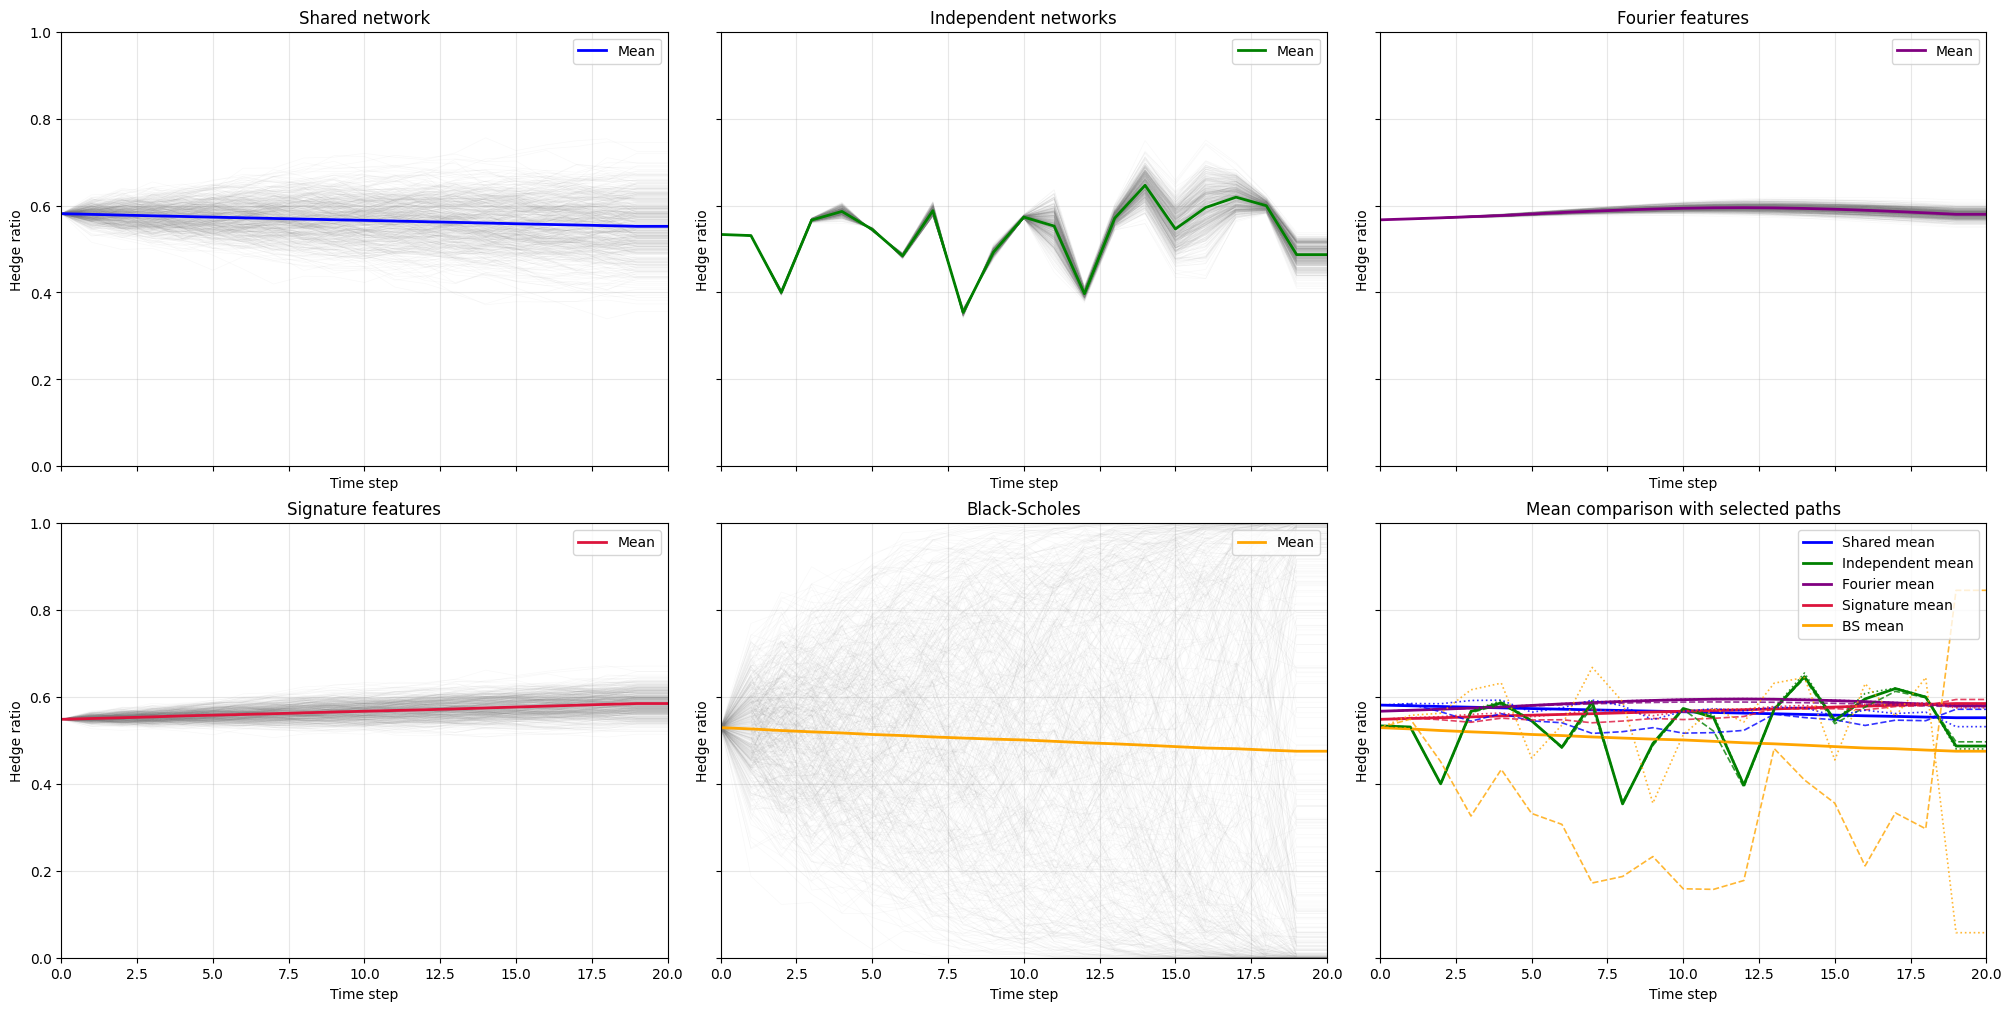

In [48]:
with torch.no_grad():
    delta_nn = hedger1.compute_hedge(derivative)[:, 0, :].cpu()
    delta_ind = hedgerN.compute_hedge(derivative)[:, 0, :].cpu()
    delta_f = hedger1f.compute_hedge(derivative)[:, 0, :].cpu()
    delta_s = hedger1s.compute_hedge(derivative)[:, 0, :].cpu()
    delta_bs = hedger_ann.compute_hedge(derivative)[:, 0, :].cpu()

time = np.arange(delta_nn.shape[1])
N_PLOT = 500

mean_nn = delta_nn.mean(dim=0)
mean_ind = delta_ind.mean(dim=0)
mean_f = delta_f.mean(dim=0)
mean_s = delta_s.mean(dim=0)
mean_bs = delta_bs.mean(dim=0)

all_deltas = torch.cat(
    [delta_nn, delta_ind, delta_f, delta_s, delta_bs]
)
ymin = all_deltas.min().item()
ymax = all_deltas.max().item()

fig, axes = plt.subplots(
    2,
    3,
    figsize=(20, 10),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

models = [
    (delta_nn, mean_nn, "Shared network", "blue"),
    (delta_ind, mean_ind, "Independent networks", "green"),
    (delta_f, mean_f, "Fourier features", "purple"),
    (delta_s, mean_s, "Signature features", "crimson"),
    (delta_bs, mean_bs, "Black-Scholes", "orange"),
]


def plot_paths(ax, deltas, mean, title, color):
    for path in deltas[:N_PLOT]:
        ax.plot(
            time,
            path,
            color="gray",
            alpha=0.05,
            linewidth=0.5,
        )

    ax.plot(
        time,
        mean,
        color=color,
        linewidth=2,
        label="Mean",
    )
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right")


for ax, model in zip(axes.flat[:5], models):
    plot_paths(ax, *model)

# Mean comparison and the same two selected paths for every method.
ax = axes.flat[5]

means = [
    (mean_nn, "blue", "Shared mean"),
    (mean_ind, "green", "Independent mean"),
    (mean_f, "purple", "Fourier mean"),
    (mean_s, "crimson", "Signature mean"),
    (mean_bs, "orange", "BS mean"),
]

for mean, color, label in means:
    ax.plot(time, mean, color=color, linewidth=2, label=label)

selected = [
    (delta_nn, "blue"),
    (delta_ind, "green"),
    (delta_f, "purple"),
    (delta_s, "crimson"),
    (delta_bs, "orange"),
]

for path, style in zip([0, 1], ["--", ":"]):
    for deltas, color in selected:
        ax.plot(
            time,
            deltas[path],
            color=color,
            linestyle=style,
            linewidth=1.2,
            alpha=0.8,
        )

ax.set_title("Mean comparison with selected paths")
ax.grid(alpha=0.3)
ax.legend(loc="upper right")

for ax in axes.flat:
    ax.set_xlim(time[0], time[-1])
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel("Time step")
    ax.set_ylabel("Hedge ratio")

plt.show()


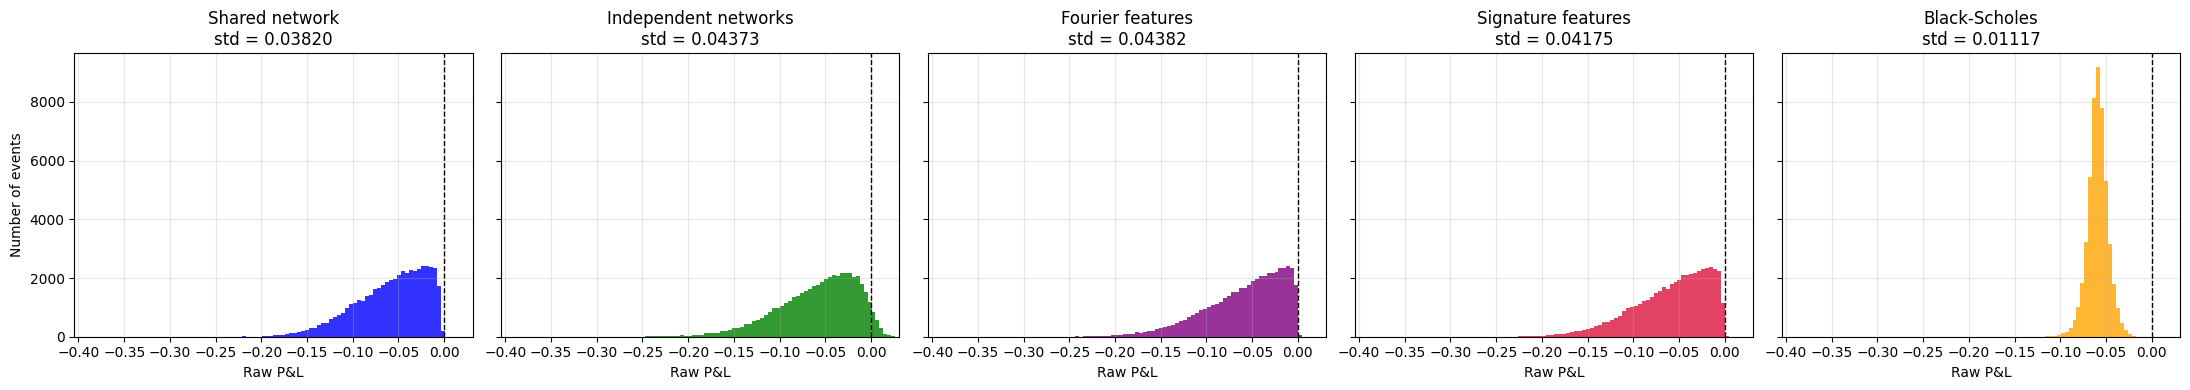

In [49]:
with torch.no_grad():
    pnl_nn = hedger1.compute_pl(derivative).cpu()
    pnl_ind = hedgerN.compute_pl(derivative).cpu()
    pnl_f = hedger1f.compute_pl(derivative).cpu()
    pnl_s = hedger1s.compute_pl(derivative).cpu()
    pnl_bs = hedger_ann.compute_pl(derivative).cpu()

all_pnl = torch.cat([pnl_nn, pnl_ind, pnl_f, pnl_s, pnl_bs])
xmin = all_pnl.min().item()
xmax = all_pnl.max().item()
bins = np.linspace(xmin, xmax, 101)

pnls = [
    (pnl_nn, "Shared network", "blue"),
    (pnl_ind, "Independent networks", "green"),
    (pnl_f, "Fourier features", "purple"),
    (pnl_s, "Signature features", "crimson"),
    (pnl_bs, "Black-Scholes", "orange"),
]

fig, axes = plt.subplots(
    1,
    5,
    figsize=(22, 4),
    sharex=True,
    sharey=True,
)

for ax, (pnl, label, color) in zip(axes, pnls):
    ax.hist(
        pnl.numpy(),
        bins=bins,
        color=color,
        alpha=0.8,
    )
    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=1,
    )
    ax.set_xlim(xmin, xmax)
    ax.set_title(f"{label}\nstd = {pnl.std():.5f}")
    ax.set_xlabel("Raw P&L")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Number of events")

plt.tight_layout()
plt.show()
